PROGETTO 2: CLASSIFICATORE IMMAGINI REALI (CIFRA10 -> RESNET)

MNIST → CNN tradizionale → CIFAR-10 → rete più profonda → ResNet

Uno dei problemi è il riconoscimenti di oggetti con resnet dataset cifra10

Con MNIST il modello riconosce cifre quasi sempre centrate, in bianco e nero, su uno sfondo pulito. Con CIFAR-10 deve riconoscere oggetti a colori inseriti in ambienti variabili.

- Implementazione di una ResNet: confronto tra blocchi residuali
- Gestione della bassa risoluzione: tecniche di upsampling e adattamento del campo ricettivo per immagini 32x32
- Analisi e report finale: metriche di valutazione e interpretazione della matrice di confuzione su 10 classi

Le classi si CIFAR10 sono: 0  airplane     aereo; 1  automobile   automobile; 2  bird         uccello; 3  cat          gatto; 4  deer         cervo; 5  dog          cane; 6  frog         rana; 7  horse        cavallo; 8  ship         nave; 9  truck        camion
Il test set contiene 10.000 immagini per ogni classe
il training set contiene 5.000 per classe

Le immagini sono piccole, le classi sono solo 10, è già pulito e organizzato, non è un vero dataset industriale, ma rimane buono per didattica
A livello professionale è possibile utilizzare ImageNet, ho molte categorie.
Non devi addestare personalmente ResNet sui 1,2 milioni di file, quel lavoro è già stato fatto.
Per utilizzare realmente un modello pre-addestrato scrivi qualcosa come:
base_model = keras.applications.ResNet50(weights="imagenet",include_top=False,input_shape=(224, 224, 3))
dove la parte importante è 'weights', vuol dire caricai i pesi che ResNet50 ha già appreso addestrandosi su ImageNet

Keras Application contiene diversi modelli disponibili con pesi preaddestrati, utilizzabili per predizione, estrazione delle feature e fine-tunong.
I pesi vengono scaricati automaticamente quando istanzi il modello
quindi, riassumento:
ImageNet: dataset di immagini usato per il pretraining
ResNet50: architettura della rete neurale
Keras Applications: catalogo da cui carichi modello e pesi


Tornando a CIFAR-10

è più difficile di MNST perchè ho una variabilità interna alla stessa classe (variabilita intra-classe)
ho un cane piccolo, uno grande, uno bianco ed uno nero, uno visto frontalmente, uno visto laterlamente, uno vicino ed uno lontano. Il modello deve imparare che immagini anche molto diverse possono appartenere alla stessa categoria
Inoltre ho somiglianda tra classi diverse, un gatto e un cane possono avere 4 zampe, 2 orecchie, 1 muso, essere pelosi, ecc
Il modello deve trovare le caratteeristiche realmenti discriminanti
Inoltre in CIFAR-10 ho una risoluzione bassissima 32x32 pixel sono pochissimi
Su un monitor l'immagine appare sfuocata perchè ogni oggetto è rappresentato da informazioni molto limitate. Il modello non può affidarsi a dettagli fini come baffi, occhi o struttura precisa del pelo, deve lavorare su forma generale, colori, texture, contorni, ec
C'è anche un altro rischio, il modello potrebbe imparare sfondo blu -> nave o aereo, sfondo verde -> cerco o rana, ecc
In questo caso il modello non sta riconoscendo realmente l'oggetto, sta sfruttando correlazioni delle sfondo

Architettura Residuale
Risolvere il degrado delle reti profonde
Le reti neurali molto profonde soffrono del problema della scomparsa del gradiente, dove l'informazione si perde attraverso i layer. 
Come il telefono senza fili, l'informazione parte per arrivare al 50esimo filo con un significato completamente diverso.

La ResNet introduce le skip connections, delle corsie preferenziali che permettono all'informazione di fluire indisturbata (gradiente di fluire indisturbato).
Vedremo come implementare un blocco residuale elementare e quando preferire l'uso di una ResNet pre-addestrata su ImageNet tramite il Transfer Learning.

Ma come funziona, matematicamente, questa scorciatoia?

Skip Connecrtions e Identità
L'idea fondamentale è aggiungere collegamenti diretti chiamati skip connection, questi collegamenti permettono all'informazione di saltare uno o più layer. La rete non deve imparare direttamente tutte le trasformazioni. Impare invece il residuo, questo è il residual learning
Esempio 
x=10 y=10,2
una rete tradizionale deve imparare direttamente 10->10,2
Una rete residuale può imparare solamente la differenza 
F(X)=0,2
Quando la trasformazione necessaria è piccola, imparare la differenza può essere più semplice che ricostruire completamente il risultato.
La Skip connection è, concettualmente, il passaggio dal record originale fino al punto in cui viene sommato alle modifiche.
Supponiamo che alcuni layer aggiuntivi non servano, questo blocco si comporta come identità, entra x esce x senza aggiungere profondità

Il cuore della ResNet
- Residual Learning: invece di chiedere ad un blocco di imparare da zero, gli chiediamo di imparare la differenza tra quello che già sa e l'obbiettivo
- Identity Mapping: la connessione scorciatoia che somma l'input originale all'output della convoluzione, preservando il segnale originale. Se  un layer non ha nulla da aggiungere può semplicemente lasciar passare l'input così come è
- Bottleneck Design: l'uso di convoluzioni 1x1 per ridurre la profondità dei filtri prima della convoluzione 3x3, ottimizzando il carico computazionale
- Vantaggio del Gradiente: le connessioni skip agiscono come autostrade che facilitano il passaggio delle derivate durante la backpropagation

Implementazione Funzionale
Tecnicamente stiamo parlando di una Somma Element-wise
Non stiamo incollando i pezzi li stiamo sommando algebricamente.
C'è però una sfida se la convoluzione dimezza la risoluzione l'input originale non combacia più, in quel caso  usiamo la Dimension Metching una piccola convoluzione 1x1 che adegua lo short cut affinche i due rami possono abbracciarsi di nuovo.

Il principio si basa sull'idea che sia più facile per la rete ottimizzare una funzione residua rispetto a una funzione ignota completa

Quindi meglio costruire questi binari a meno, o utilizzare una linea già esistente?

Custom vs Pre-trained
Strategia di sviluppo
Creare una ResNet custom permette un controllo totale sui parametri, ideale per dataset piccoli come CIFAR-10 dove una ResNet50 potrebbe causare overfitting
Dall'altra parte il Transfer Learning, con modelli pre-addestrati, è come compare un abito di alta moda, è potentissimo ma dobbiamo adattarlo alla nostra taglia. Rimane comunque un'opzione valida se si utilizzano tecniche di fine-tuning oculate e si bloccano i layer iniziali

Ma c'è un problema fisico Cifar10 è minuscolo, è composto da immagini 32x32 pixel. Le architetture ResNet standard sono progettate per input 224x224, il che porta a una perdita di risoluzione troppo rapida.
E' come cercare di guardare un francobollo con un telescopio tarato per le stelle, vedresti solo sfuocato.
Se applichiamo troppi passaggi di riduzione (stride) dopo pochi layer la nostra immagine diverebbe un singolo pixel perdendo di significato. Dobbiamo imparare a preservare la risoluzione.
Dobbiamo modificare lo stride iniziale o utilizzare layer di upsampling per garantire che le feature map mantengano un dettaglio sufficiente per la classificazione
Dobbiamo agire direttamente sull'architettura

Adattamento Architetturale
Preservare i pixel
- Upsampling Layer:  utilizzo di un layer UpSampling2D o Lambda per ridimensionare (ingrandire) le immagini prima dell'ingresos nella rete
- Stride Modification: rimozione del max-pooling iniziale e modifica dello stride 2x2 in 1x1 nei primi blocchi della ResNet. Invece di partire con un passo 'pesante' partiamo a passi piccoli (1x1) per mantenere l'immagine nitida più a lungo
- Campo Ricettivo: bilanciamento della profondità affinchè i filtri finali non coprano un'area superiore all'intera immagine 32x32
- Data Augmentation: uso di padding e crop casuali per rendere il modello più resiliente alla scarsità di dettagli spaziali.

E per quanto riguarda la stabiltà del segnale in ingresso?

Pipeline di Input
Nel ridimensionamento delle immagini, l'interpolazione gioca un ruolo chiave nel mantenere i bordi definiti  per i filtri convoluzionali.
La Batch Normalizzation è essenziale per gestire immagini piccole, poichè stabilizza le attivazioni che potrebbero oscillare drasticamente a casusa della bassa varianza locale.
La risoluzione decresce geometricamente; in cifar-10 dobbiamo evitare che la mappa diventi 1x1 prima dell ultimo blocco residuale.
Dobbiamo monitorare la situazione ad ogni passo per assicurarci di arrivare in cima con le informazioni ancora leggibili.

Vediamo le varianti nate per questa sfida
Esistono delle versione junior della ResNet, come la ResNet-20 e 32, pensate appositamente per CIFAR-10, che eliminano i layer di pooling iniziali pesanti
Questi adattamenti permettono di addestrare modelli molto profondi senza perdere la tipologia delle piccole immagini in input
Tutte queste varianti permettono di avere tutta la potenza del residual learning senza l'ingombro dei parametri innutili 
Questo perchè se l'immagine è 32x32 non puoi dimezzarla più di 5 volte prima di arrivare a zero.

Una volta addestrata la nostra creatura dobbiamo interrogarla

Report di Valutazione
L'obbiettivo finale è una analisi onesta delle performance. Non basta guardare l'accuratezza totale, dobbiamo capire quali classi vengono confuse.
Analizzeremo come produrre un report professionale che includa metriche per classe e una visualizzazione chiara dei risultati ottenuti sul test set.
Un ricercatore serie non punterebbe mai solo al 90% di accuratezza, deve essere onesto, cercando di capire dove sbaglia.

Quali strumenti diagnostici si possono usare?

Diagnostica del modello
- Precision e Recall: fondamentali per distinguere errori di 'falso allarme' da 'mancato rilevamento' tra classi simili come cane e gatto. Precision per sapere quanti sono i risultati affidabili, mentre la Recall per capire quanti dati ci siamo persi
- Matrice di Confuzione: strumento visivo per identificare i bias del modello verso classi dominanti o feature ambigue
- F1-Score: la media armonica che fornisce un valore sintetico della qualità del classificatore, pesando correttamente errori di tipo I e II. F1-Score è una media di Precisione e Recall
- Analisi degli Errori: ispezione visiva dei campioni classificati erroneamente per comprender se il limite è nei dati o nel modello.

Ma i numeri non sono tutto, dobbiamo guardare anche la storia del training

Reporting Avanzato
Le Curve di Apprendimento sono il nostro diario di bordo, se il trainig scende e quello di validation sale stiamo overfittando.
E dobbiamo misurare anche la letenza di predizione per capire se la ResNet è adatta ad applicazioni in tempo reale.
Abbiamo poi anche la Top-K-Accuracy metrica utile in dataset complessi per verificare se la classe corretta è tra le prime 'k' predizioni del modello.

Tutti questi dati raccolti ed ottimizzati dobbiamo trasformarli in decisioni

Interpretazione dei Risultati
Verso il Deploy
Un buon report giustifica le scelte.
Un'accuratezza superiore al 85% su CIFAR-10 con una ResNet custom è considerata un ottimo risultato per sistemi non pre-addestrati.
Il report finale deve giustificare ogni scelta architetturale basandosi sull'evidenza numerica raccolta durante la fase di test.



Model: "ResNet_CIFAR10_2026"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 32,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │     18,496 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │     36,928 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │      2,112 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 32, 32,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 16,    │     73,856 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 16, 16,    │    147,584 │ activation_3[0][

 Total params: 1,214,538 (4.63 MB)

 Trainable params: 1,211,786 (4.62 MB)

 Non-trainable params: 2,752 (10.75 KB)


[INFO] Avvio addestramento con backend PyTorch...


c:\EPICODE\Epicode_Python_AI_MachineLearning\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 74s 94ms/step - accuracy: 0.5660 - loss: 1.2091 - val_accuracy: 0.5574 - val_loss: 1.2804 - learning_rate: 0.0010
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 84s 108ms/step - accuracy: 0.7089 - loss: 0.8224 - val_accuracy: 0.6350 - val_loss: 1.0682 - learning_rate: 0.0010
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 84s 108ms/step - accuracy: 0.7726 - loss: 0.6559 - val_accuracy: 0.6492 - val_loss: 1.0580 - learning_rate: 0.0010
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 84s 108ms/step - accuracy: 0.8137 - loss: 0.5373 - val_accuracy: 0.6787 - val_loss: 1.0812 - learning_rate: 0.0010
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 85s 108ms/step - accuracy: 0.8450 - loss: 0.4495 - val_accuracy: 0.7123 - val_loss: 0.8882 - learning_rate: 0.0010
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 84s 107ms/step - accuracy: 0.8725 - loss: 0.3667 - val_accuracy: 0.7407 - val_loss: 0.8224 - learning_rate: 0.0010
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 106ms/step - accuracy: 0.89

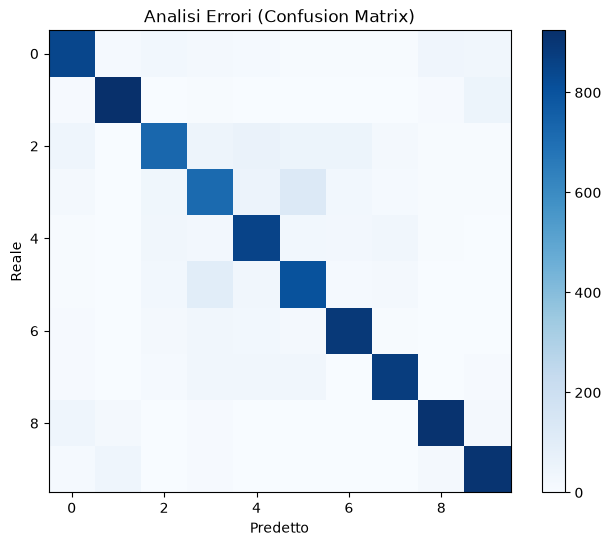

In [3]:
#AI Overview
#Modelli e pipeline di codice mostrano esplorazione di Keras 3, implementazione di reti neurali (RNN/CNN) e tecniche di ottimizzazione del training.

import os

# 1. CONFIGURAZIONE BACKEND (Best Practice 2026)
# Keras 3 permette di scegliere il motore di calcolo (backend). 
# Impostiamo "torch" prima di importare keras per sfruttare l'ecosistema PyTorch.
# Teoria: L'agnosticismo del backend permette di addestrare su un framework e distribuire su un altro.
os.environ["KERAS_BACKEND"] = "torch"

import keras
from keras import layers, models, ops
import numpy as np
import tensorflow as tf # Utilizzato esclusivamente per la pipeline tf.data (standard industriale per prefetch)
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# ==========================================
# 2. PIPELINE DATI OTTIMIZZATA (Prefetch & Cache)
# ==========================================

def prepare_dataset(x, y, training=True):
    """
    Crea una pipeline di dati performante.
    Teoria: Il collo di bottiglia nel DL è spesso il caricamento dati (CPU) rispetto al calcolo (GPU).
    """
    # Creiamo un oggetto Dataset dai tensori NumPy
    dataset = tf.data.Dataset.from_tensor_slices((x, y))
    
    # [TEORIA] Normalizzazione: Portiamo i pixel da [0, 255] a [0, 1].
    # Input piccoli e centrati evitano che i gradienti esplodano durante le prime epoche.
    dataset = dataset.map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y), 
                          num_parallel_calls=tf.data.AUTOTUNE)
    
    # [CACHE] Memorizza i dati in RAM dopo la prima lettura.
    # Evita di ripetere le operazioni di decodifica/preprocessing ad ogni epoca.
    dataset = dataset.cache()
    
    if training:
        # [SHUFFLE] Fondamentale per la convergenza: evita che il modello impari l'ordine dei dati.
        dataset = dataset.shuffle(buffer_size=5000)
    
    # Batching: raggruppiamo i dati.
    dataset = dataset.batch(64)
    
    # [PREFETCH] La "Killer Feature" per le performance.
    # Mentre la GPU calcola il gradiente del batch corrente (N), 
    # la CPU prepara già il batch successivo (N+1) in background.
    # AUTOTUNE decide dinamicamente quanti batch precaricare in base alle risorse.
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
    
    return dataset

# Caricamento dati CIFAR-10
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = keras.datasets.cifar10.load_data()

# Preparazione pipeline
train_ds = prepare_dataset(x_train_raw, y_train_raw, training=True)
test_ds = prepare_dataset(x_test_raw, y_test_raw, training=False)

# ==========================================
# 3. ARCHITETTURA: RESNET CUSTOM (API Funzionale)
# ==========================================

def residual_block(x, filters, stride=1):
    """
    Blocco Residuale (ResNet). 
    Teoria: Introduce le 'skip connections' per risolvere il problema della scomparsa del gradiente.
    Permette ai gradienti di fluire direttamente attraverso la rete durante la backpropagation.
    """
    shortcut = x
    
    # Percorso principale - Primo blocco: Conv -> BN -> Activation
    # La Batch Normalization stabilizza l'apprendimento normalizzando le attivazioni medie.
    x = layers.Conv2D(filters, 3, strides=stride, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    
    # Secondo blocco: Conv -> BN
    x = layers.Conv2D(filters, 3, strides=1, padding="same")(x)
    x = layers.BatchNormalization()(x)
    
    # [MATCHING DIMENSIONI] Se cambiamo risoluzione (stride > 1), dobbiamo adattare anche lo shortcut
    # in modo che la somma element-wise sia matematicamente possibile.
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding="same")(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
        
    # [TEORIA] H(x) = F(x) + x. Aggiungiamo l'input originale all'output trasformato.
    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)
    return x

def build_model(input_shape=(32, 32, 3), num_classes=10):
    inputs = layers.Input(shape=input_shape)
    
    # Layer iniziale di estrazione feature (Stem)
    x = layers.Conv2D(32, 3, padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    
    # Stack di blocchi residuali con aumento progressivo dei filtri
    x = residual_block(x, 64)
    x = residual_block(x, 128, stride=2) # Dimezza risoluzione (16x16)
    x = residual_block(x, 256, stride=2) # Dimezza risoluzione (8x8)
    
    # [GLOBAL AVERAGE POOLING] Best practice 2026 al posto del Flatten().
    # Riduce il numero di parametri e rende il modello più robusto alle traslazioni spaziali.
    x = layers.GlobalAveragePooling2D()(x)
    
    # Output layer con Softmax per classificazione multi-classe.
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    
    return models.Model(inputs, outputs, name="ResNet_CIFAR10_2026")

model = build_model()
model.summary()

# ==========================================
# 4. COMPILAZIONE E TRAINING
# ==========================================

# [ADAMW] Optimizer standard nel 2026: Adam con Weight Decay integrato per una migliore regolarizzazione.
model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# [CALLBACKS] Automazione del training
callbacks = [
    # Riduce il LR se la loss smette di migliorare (ottimizzazione fine)
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3),
    # Ferma il training per evitare l'overfitting
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

print("\n[INFO] Avvio addestramento con backend PyTorch...")
history = model.fit(
    train_ds, 
    validation_data=test_ds, 
    epochs=10, 
    callbacks=callbacks
)

# ==========================================
# 5. SALVATAGGIO MODELLO (Formato 2026)
# ==========================================

# Il formato .keras è lo standard V3: contiene pesi, architettura e stato dell'ottimizzatore.
# È un file compresso e platform-independent.
model.save("cifar10_model_v2026.keras")
print(f"\n[INFO] Modello salvato con successo: cifar10_model_v2026.keras")

# ==========================================
# 6. VALUTAZIONE E ANALISI
# ==========================================

# Generazione predizioni
y_pred_all = []
y_true_all = []

for x_batch, y_batch in test_ds:
    preds = model.predict(x_batch, verbose=0)
    y_pred_all.extend(np.argmax(preds, axis=1))
    y_true_all.extend(y_batch.numpy())

# Report di classificazione
target_names = ['Aereo', 'Auto', 'Uccello', 'Gatto', 'Cervo', 'Cane', 'Rana', 'Cavallo', 'Nave', 'Camion']
print("\n--- PERFORMANCE SUL TEST SET ---")
print(classification_report(y_true_all, y_pred_all, target_names=target_names))

# Matrice di Confusione Visiva
cm = confusion_matrix(y_true_all, y_pred_all)
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Analisi Errori (Confusion Matrix)")
plt.colorbar()
plt.xlabel("Predetto")
plt.ylabel("Reale")
plt.show()